In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/')
from spk_lfp_cluster_comp_analysis import *
from spk_feat_cluster_comp_analysis import compile_experiment_results

In [2]:
# Load LFP sliding window stats
df_pop_stats, pop_traces = compile_lfp_stats()

In [3]:
# Load cluster + metadata master table
cluster_pickle_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/'
df_master = compile_experiment_results(cluster_pickle_dir)

### Step 1: Merge LFP stats with cluster metadata

Join on `cell_id` + `spike_feature` to bring in: nRMSE, cos_sim, num_clusters, temporal_rho, temporal_component, cell_type, patch_type, cortical_depth, dark_neuron, clear_EAP_waveform.

In [4]:
# Normalize spike_feature names for joining
# df_pop_stats has e.g. 'peak_amp_cluster', df_master has 'peak_amp'
df_pop_stats['spike_feature_base'] = df_pop_stats['spike_feature'].str.replace('_cluster', '')

# Aggregate df_master to one row per cell x spike_feature (drop cluster-level rows)
meta_cols = ['cell_id', 'spike_feature', 'patch_type', 'current_type', 'cell_type',
             'cortical_depth', 'dark_neuron', 'clear_EAP_waveform',
             'num_clusters', 'nRMSE', 'cos_sim', 'temporal_rho', 'temporal_p', 'temporal_component']

df_meta = (
    df_master[meta_cols]
    .copy()
    .assign(**{c: pd.to_numeric(df_master[c], errors='coerce')
               for c in ['nRMSE', 'cos_sim', 'temporal_rho', 'temporal_component', 'cortical_depth']})
    .groupby(['cell_id', 'spike_feature'], as_index=False)
    .agg({
        'patch_type': 'first', 'current_type': 'first', 'cell_type': 'first',
        'cortical_depth': 'first', 'dark_neuron': 'first', 'clear_EAP_waveform': 'first',
        'num_clusters': 'first',
        'nRMSE': 'mean', 'cos_sim': 'mean',
        'temporal_rho': 'first', 'temporal_p': 'first', 'temporal_component': 'first'
    })
)

# Aggregate LFP stats to one row per cell x spike_feature x lfp_feature
df_lfp_agg = (
    df_pop_stats
    .groupby(['cell_id', 'spike_feature_base', 'lfp_feature'], as_index=False)
    .agg(
        n_sig_windows=('cohens_d', 'count'),
        median_cohens_d=('cohens_d', 'median'),
        max_cohens_d=('cohens_d', 'max'),
        min_pvalue=('p_value', 'min'),
    )
    .rename(columns={'spike_feature_base': 'spike_feature'})
)

# Merge
df_merged = df_lfp_agg.merge(df_meta, on=['cell_id', 'spike_feature'], how='left')
print(f'Merged df: {df_merged.shape}')
df_merged.head()

Merged df: (102, 19)


,cell_id,spike_feature,lfp_feature,n_sig_windows,median_cohens_d,max_cohens_d,min_pvalue,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,num_clusters,nRMSE,cos_sim,temporal_rho,temporal_p,temporal_component
0,c10,log_isi,Aperiodic Exponent,1,0.288919,0.288919,0.010745,Juxta,VC,PC,718.0,False,False,3,0.009306,0.99868,-0.054426,0.161261,0.0
1,c10,log_isi,Aperiodic Offset,1,0.284331,0.284331,0.012064,Juxta,VC,PC,718.0,False,False,3,0.009306,0.99868,-0.054426,0.161261,0.0
2,c10,log_isi,Gamma AUC,2,0.264374,0.306202,0.016346,Juxta,VC,PC,718.0,False,False,3,0.009306,0.99868,-0.054426,0.161261,0.0
3,c10,log_isi,LFP Spectral Exponent,1,0.277746,0.277746,0.013509,Juxta,VC,PC,718.0,False,False,3,0.009306,0.99868,-0.054426,0.161261,0.0
4,c10,log_isi,r-squared,2,0.291816,0.323242,0.010179,Juxta,VC,PC,718.0,False,False,3,0.009306,0.99868,-0.054426,0.161261,0.0


### Step 2: Does LFP effect size (Cohen's d) correlate with spike waveform differences across clusters?

Do cells with stronger spike cluster differences (high nRMSE, low cos_sim) also show stronger LFP effects?

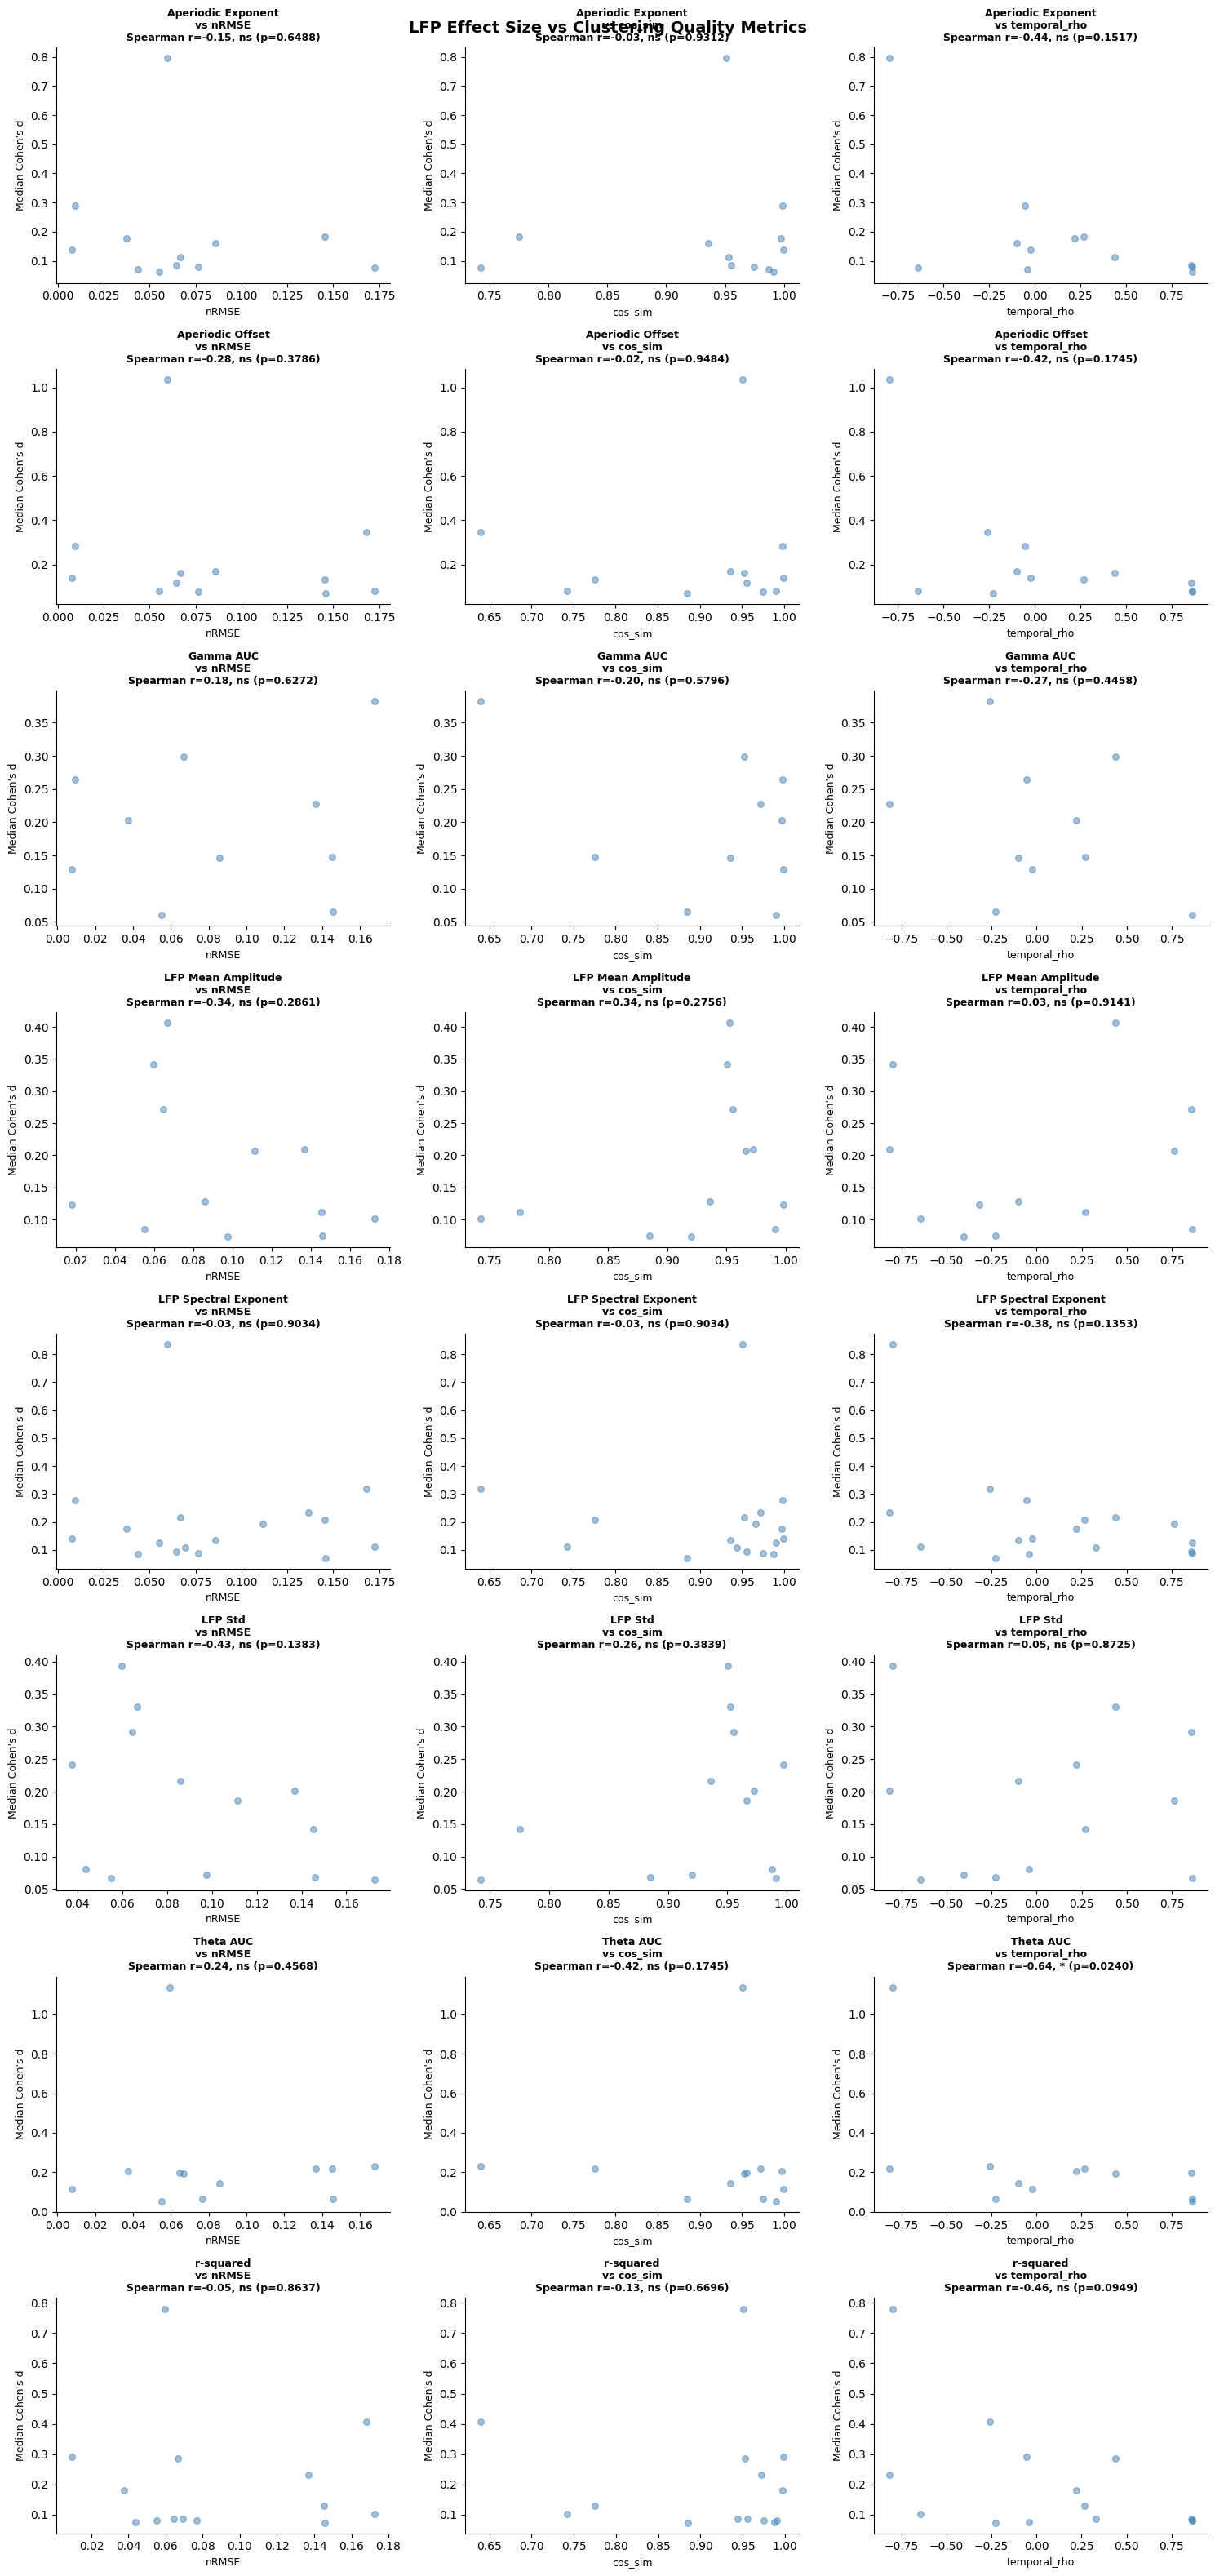

In [5]:
from scipy.stats import spearmanr

clust_metrics = ['nRMSE', 'cos_sim', 'temporal_rho']
lfp_feats = sorted(df_merged['lfp_feature'].unique())

fig, axes = plt.subplots(len(lfp_feats), len(clust_metrics),
                          figsize=(5 * len(clust_metrics), 4 * len(lfp_feats)))

for i, lfp in enumerate(lfp_feats):
    for j, met in enumerate(clust_metrics):
        ax = axes[i, j]
        sub = df_merged[df_merged['lfp_feature'] == lfp][['median_cohens_d', met]].dropna()
        ax.scatter(sub[met], sub['median_cohens_d'], alpha=0.5, s=30, color='steelblue')
        if len(sub) >= 3:
            rho, p = spearmanr(sub[met], sub['median_cohens_d'])
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            p_str = f'{p:.4f}' if p >= 0.0001 else '<0.0001'
            ax.set_title(f'{lfp}\nvs {met}\nSpearman r={rho:.2f}, {sig} (p={p_str})', fontsize=9, fontweight='bold')
        else:
            ax.set_title(f'{lfp} vs {met}\n(n<3)', fontsize=9)
        ax.set_xlabel(met, fontsize=9)
        ax.set_ylabel("Median Cohen's d", fontsize=9)
        sns.despine(ax=ax)

plt.suptitle('LFP Effect Size vs Clustering Quality Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3: Does cell metadata predict LFP effect size or yield?

Do cortical depth, cell type, patch type, or dark neuron status predict how strongly/often LFP effects appear?

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  

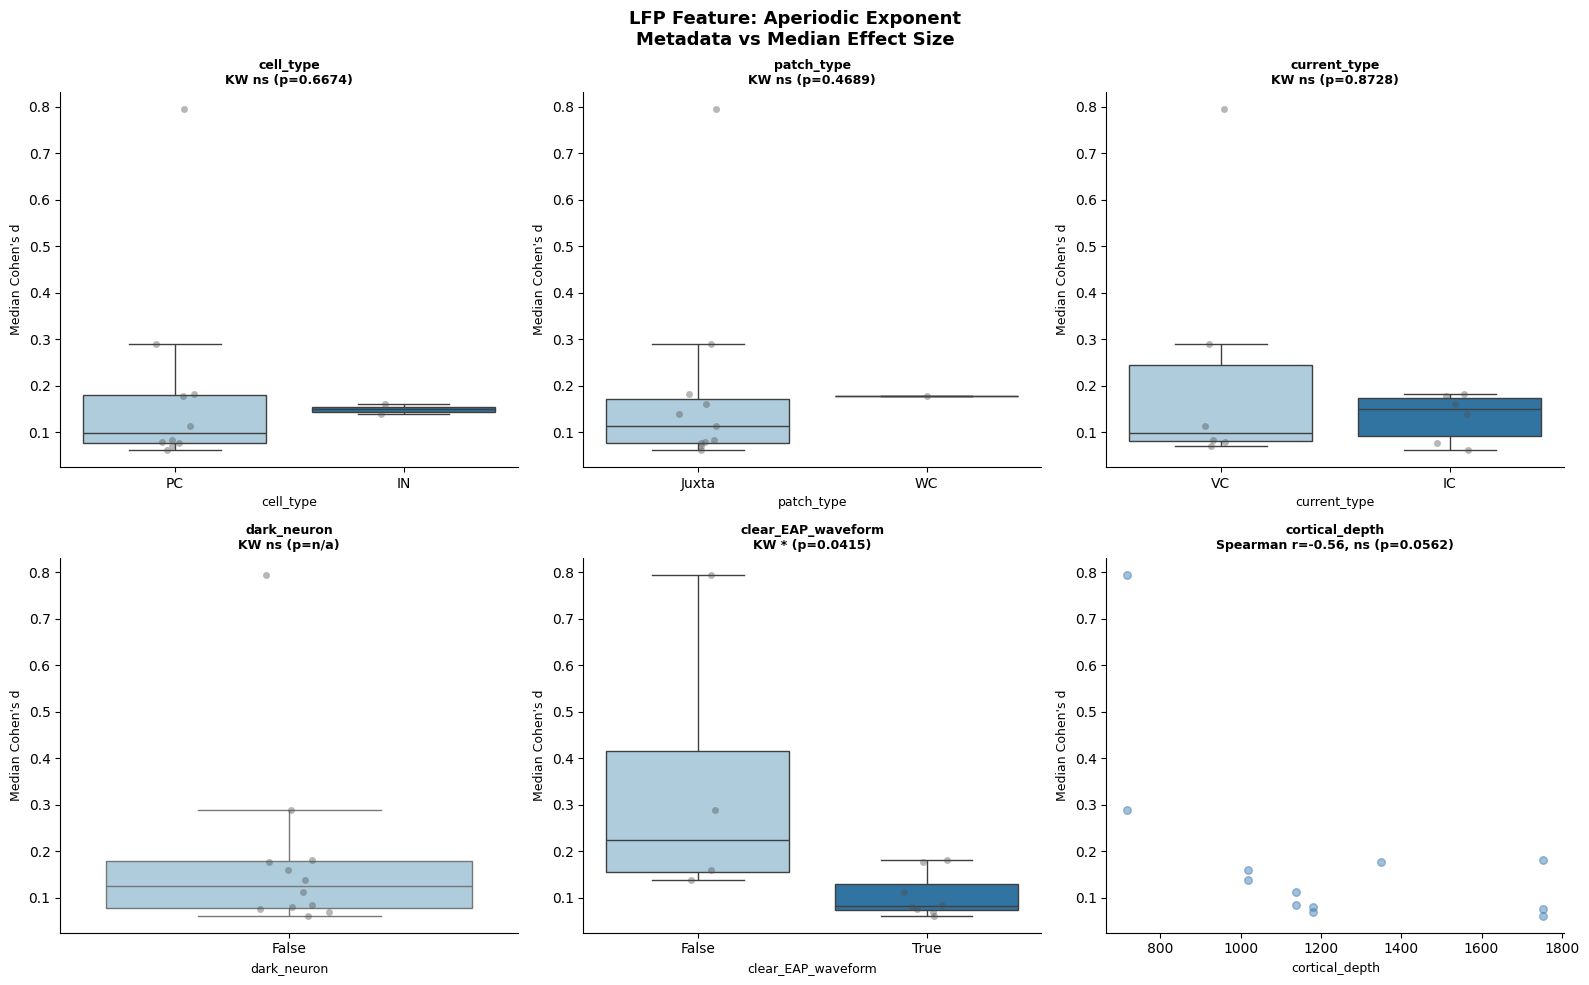

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  

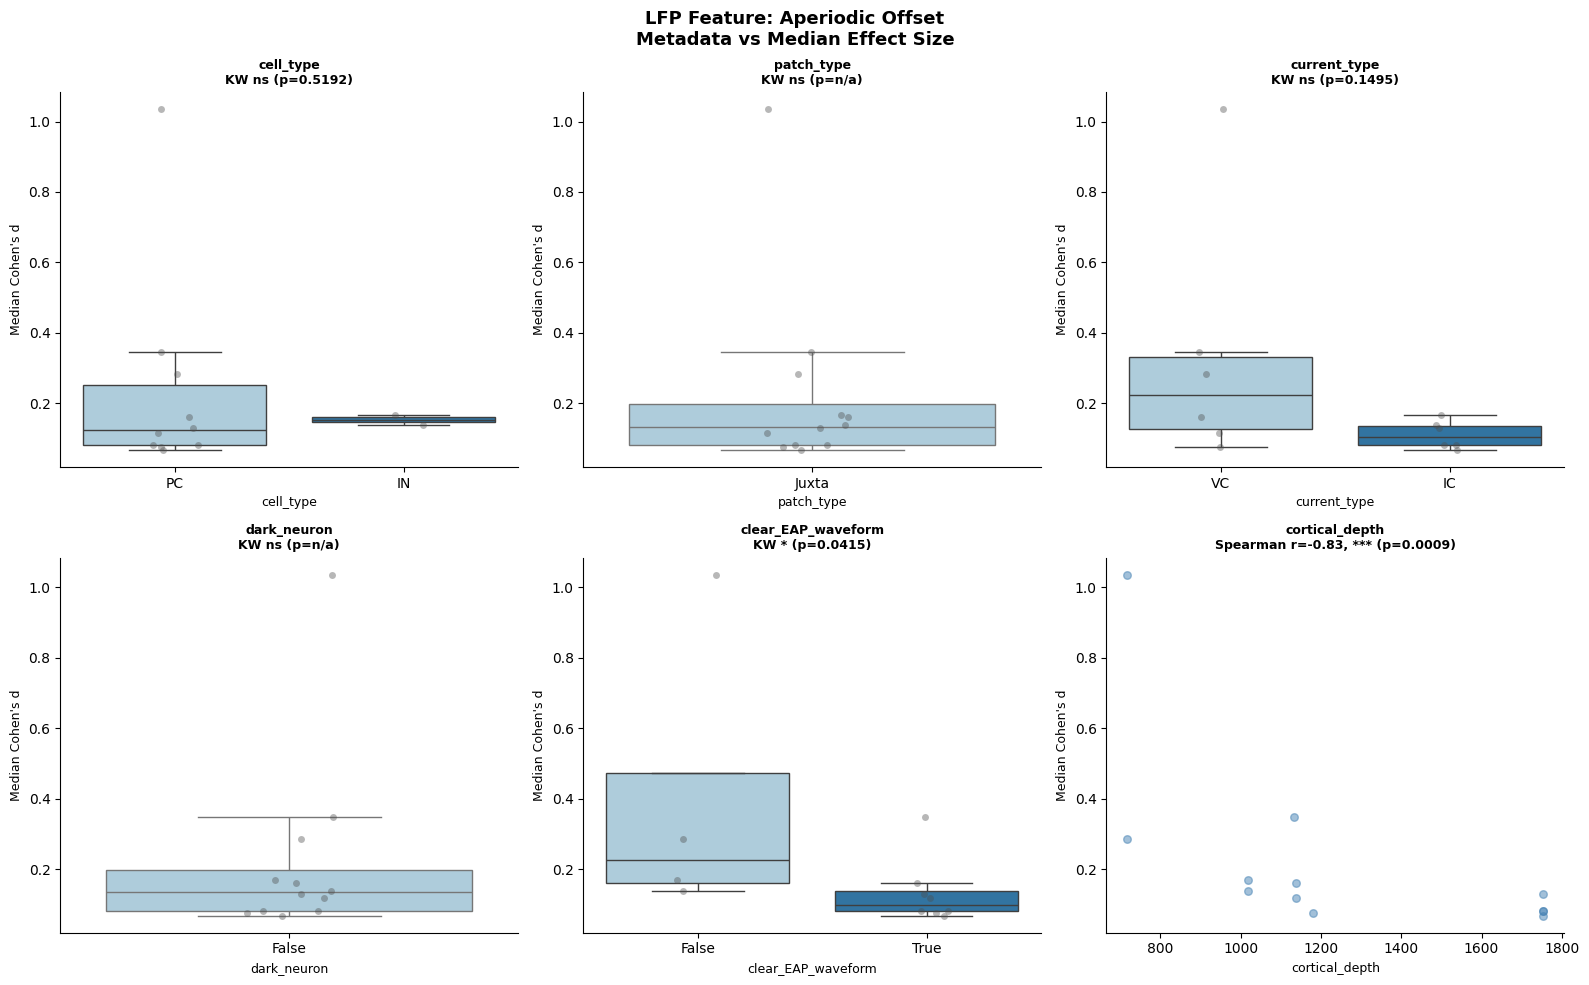

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  

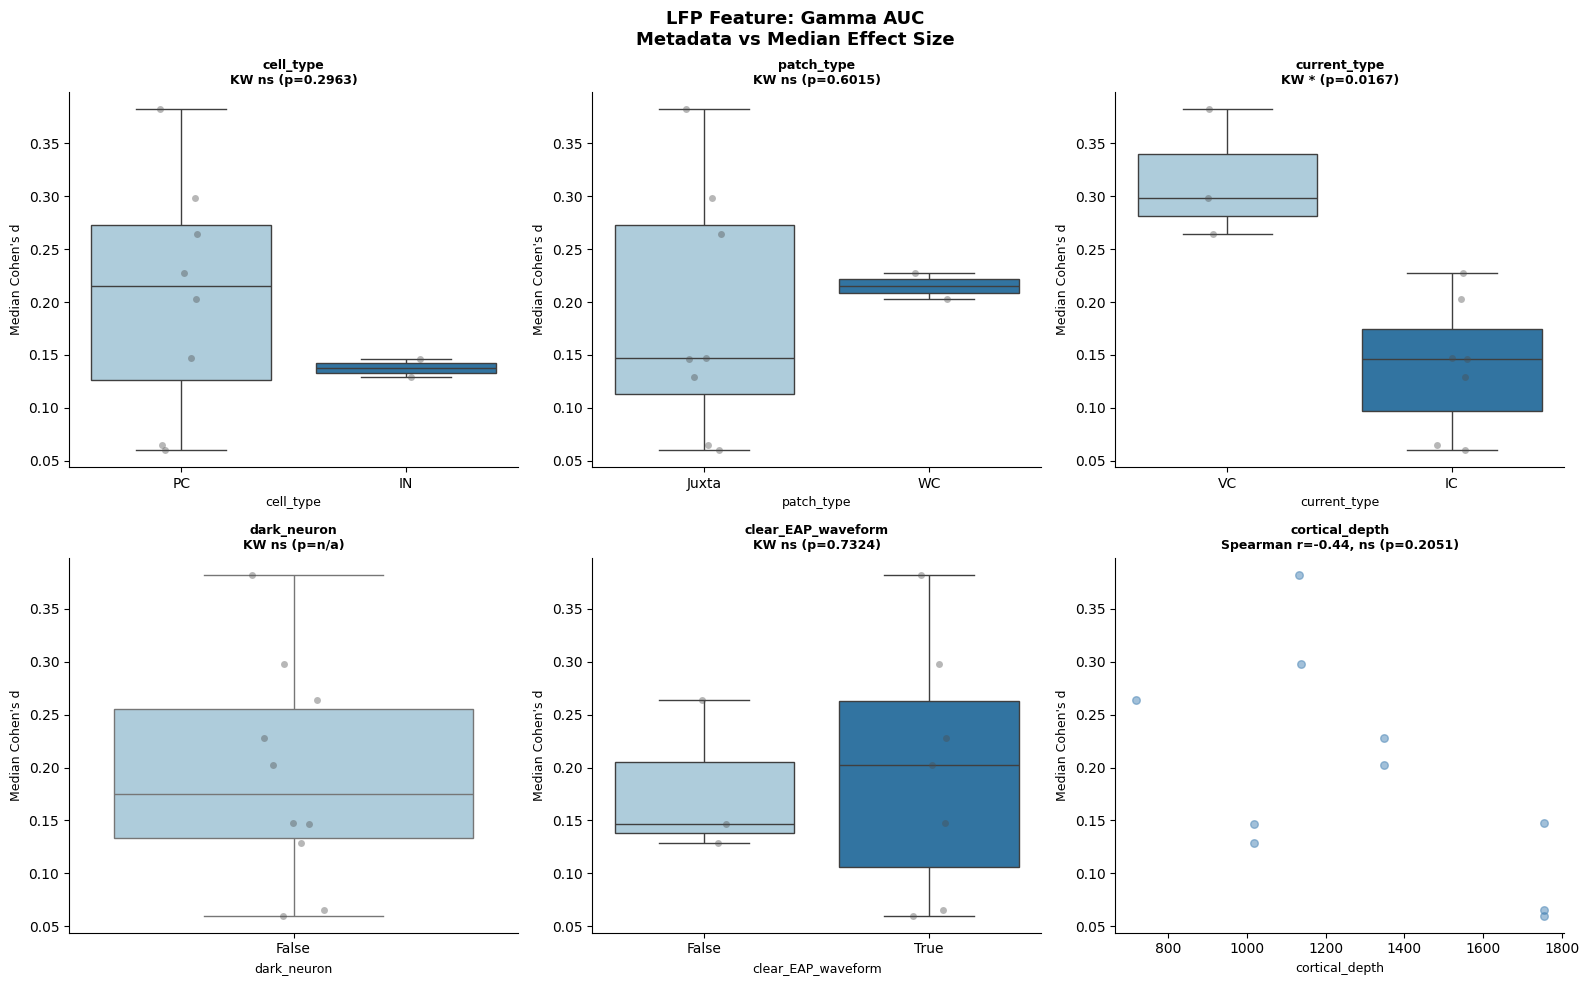

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  

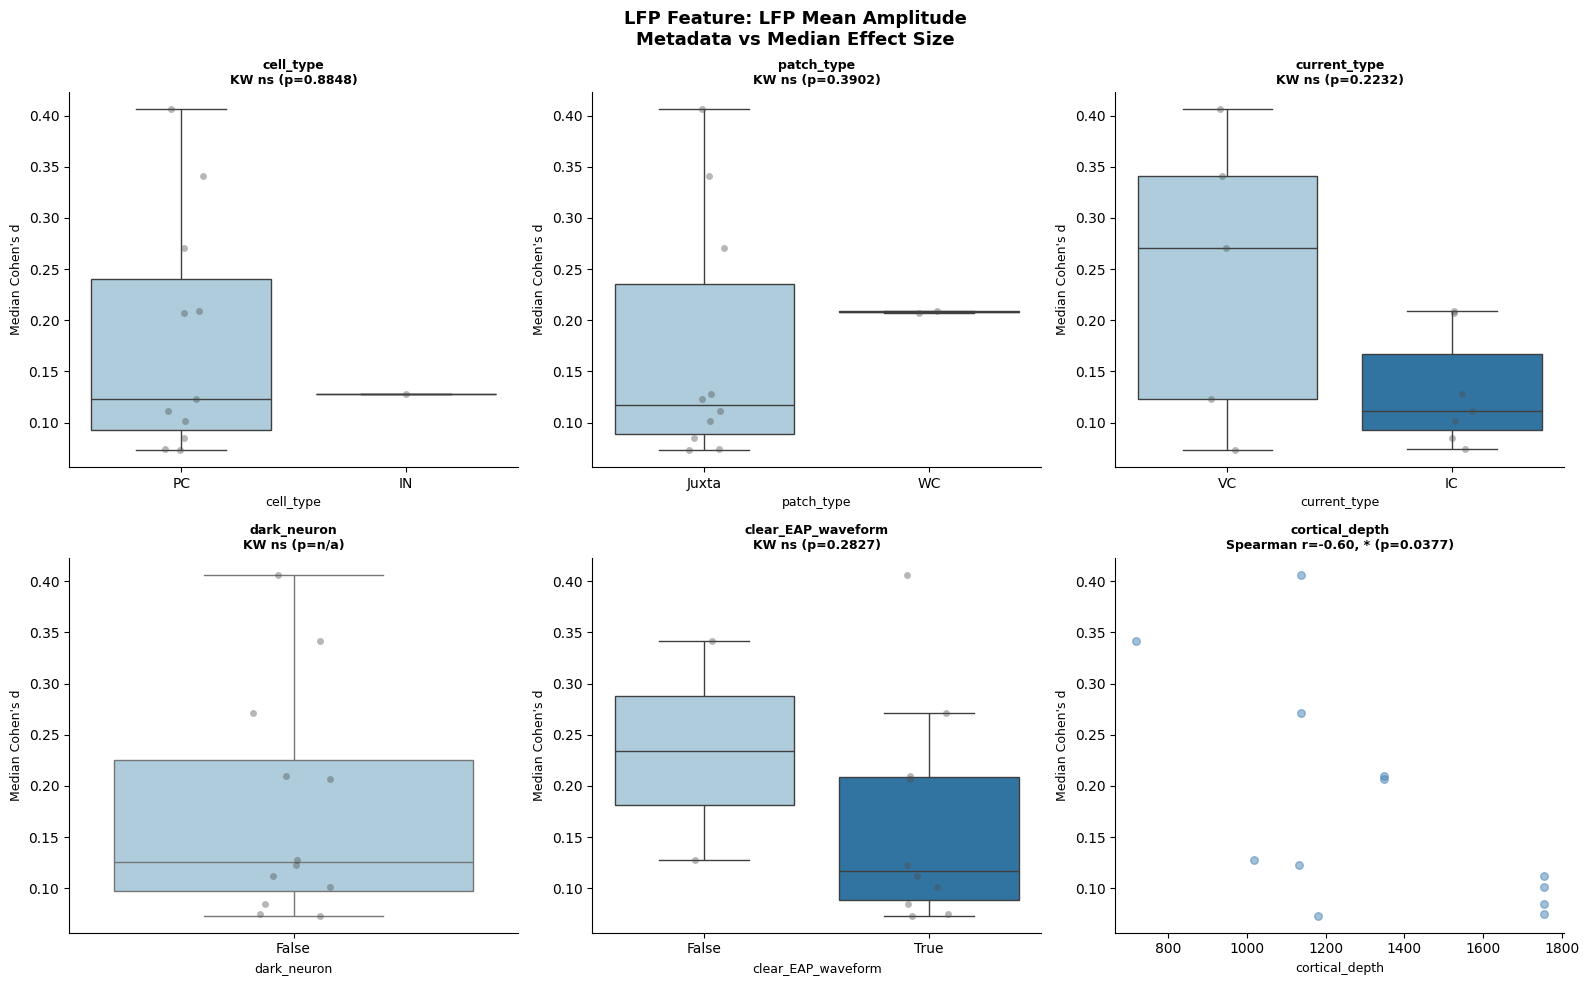

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  

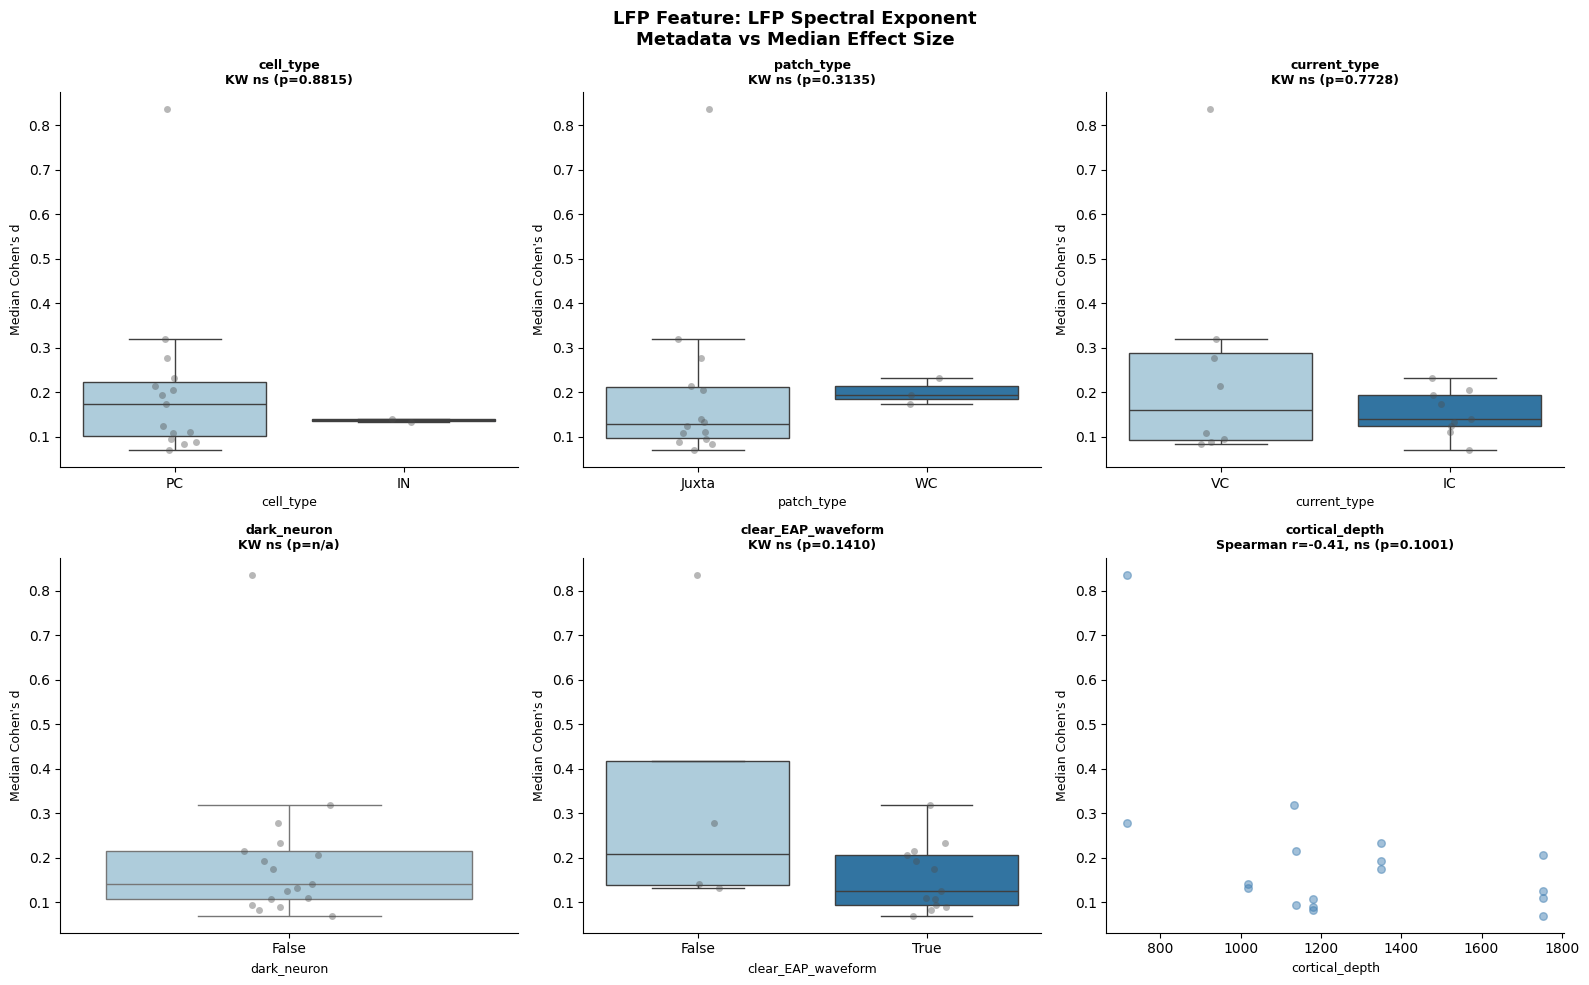

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  

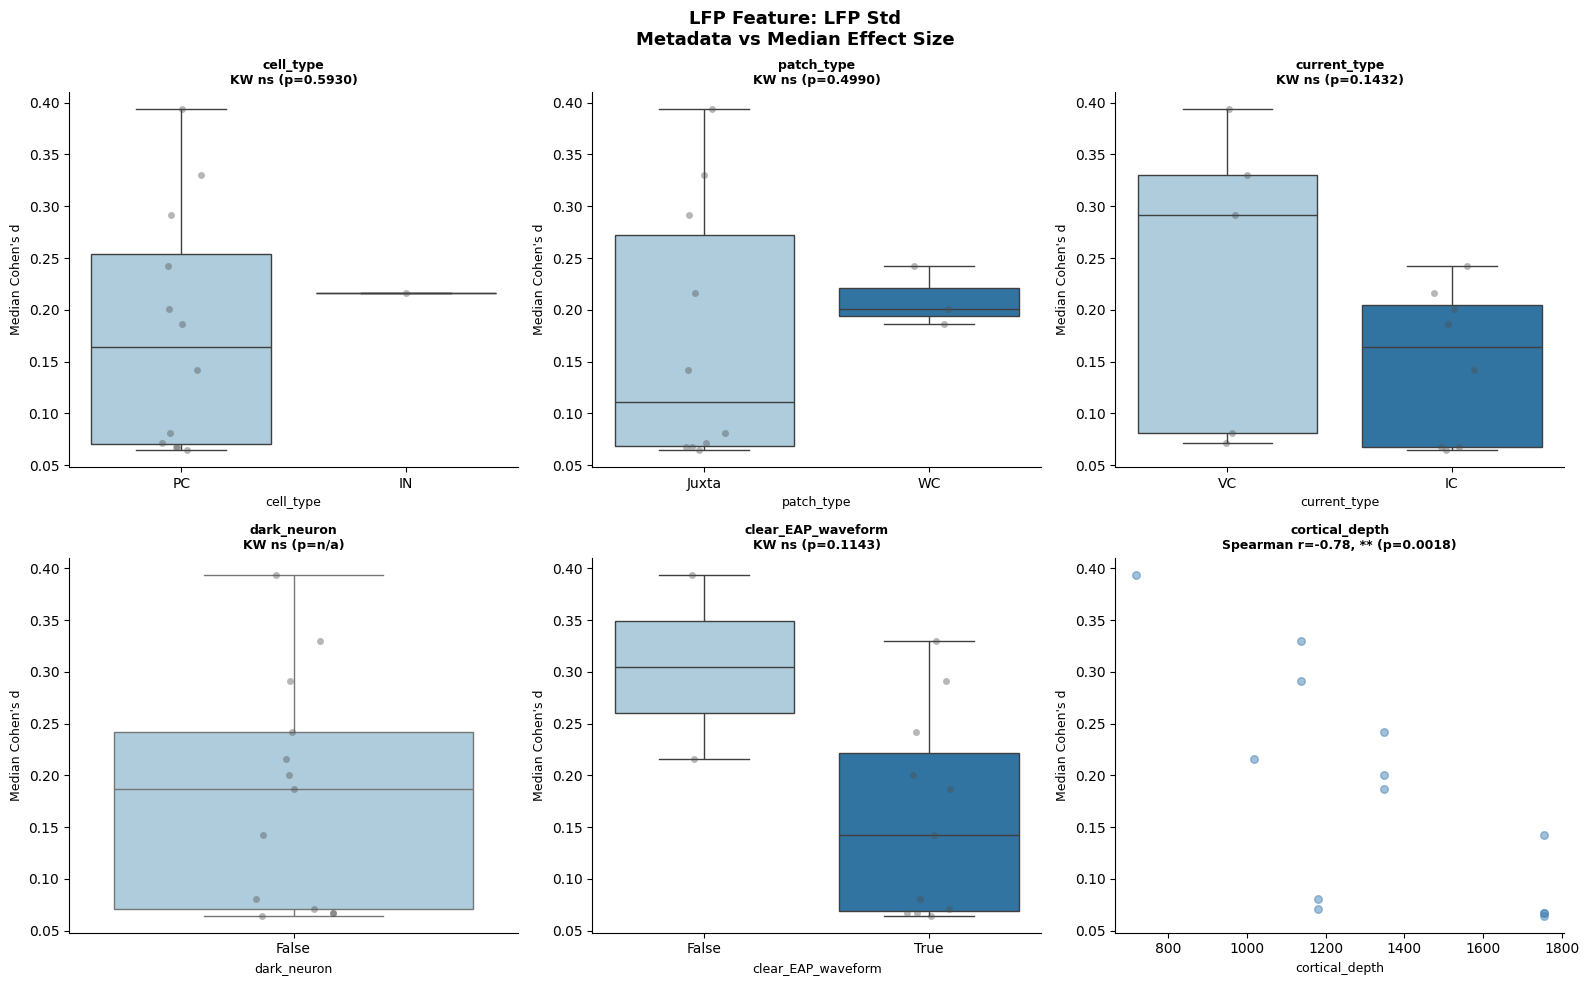

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  

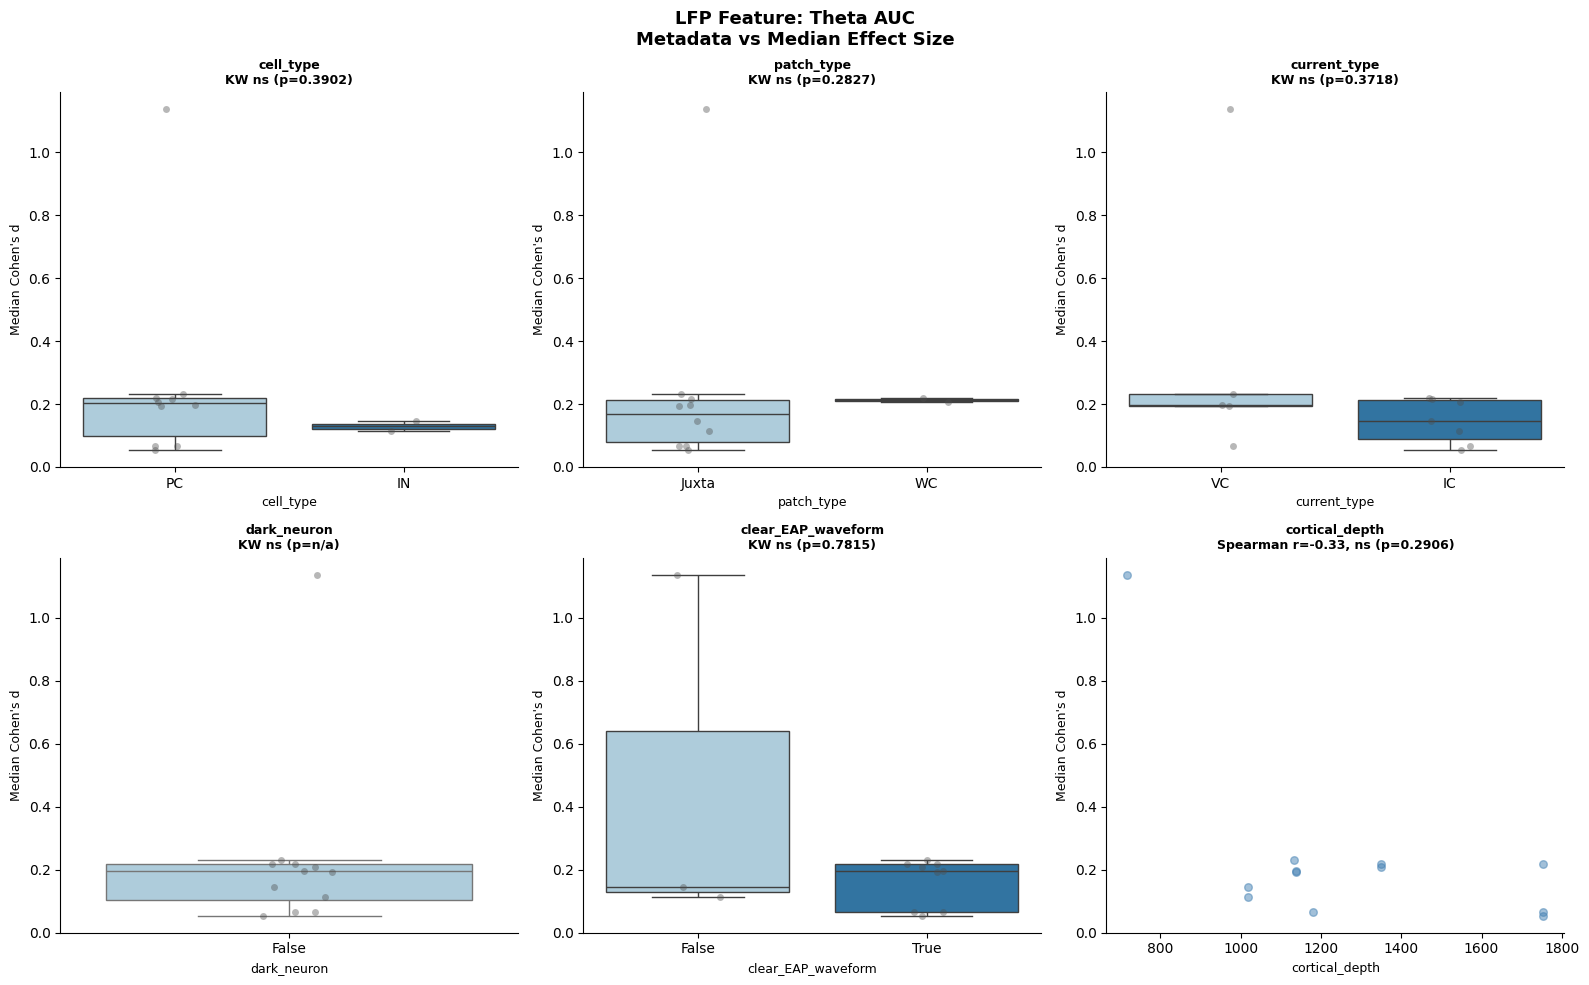

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2053102333.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  

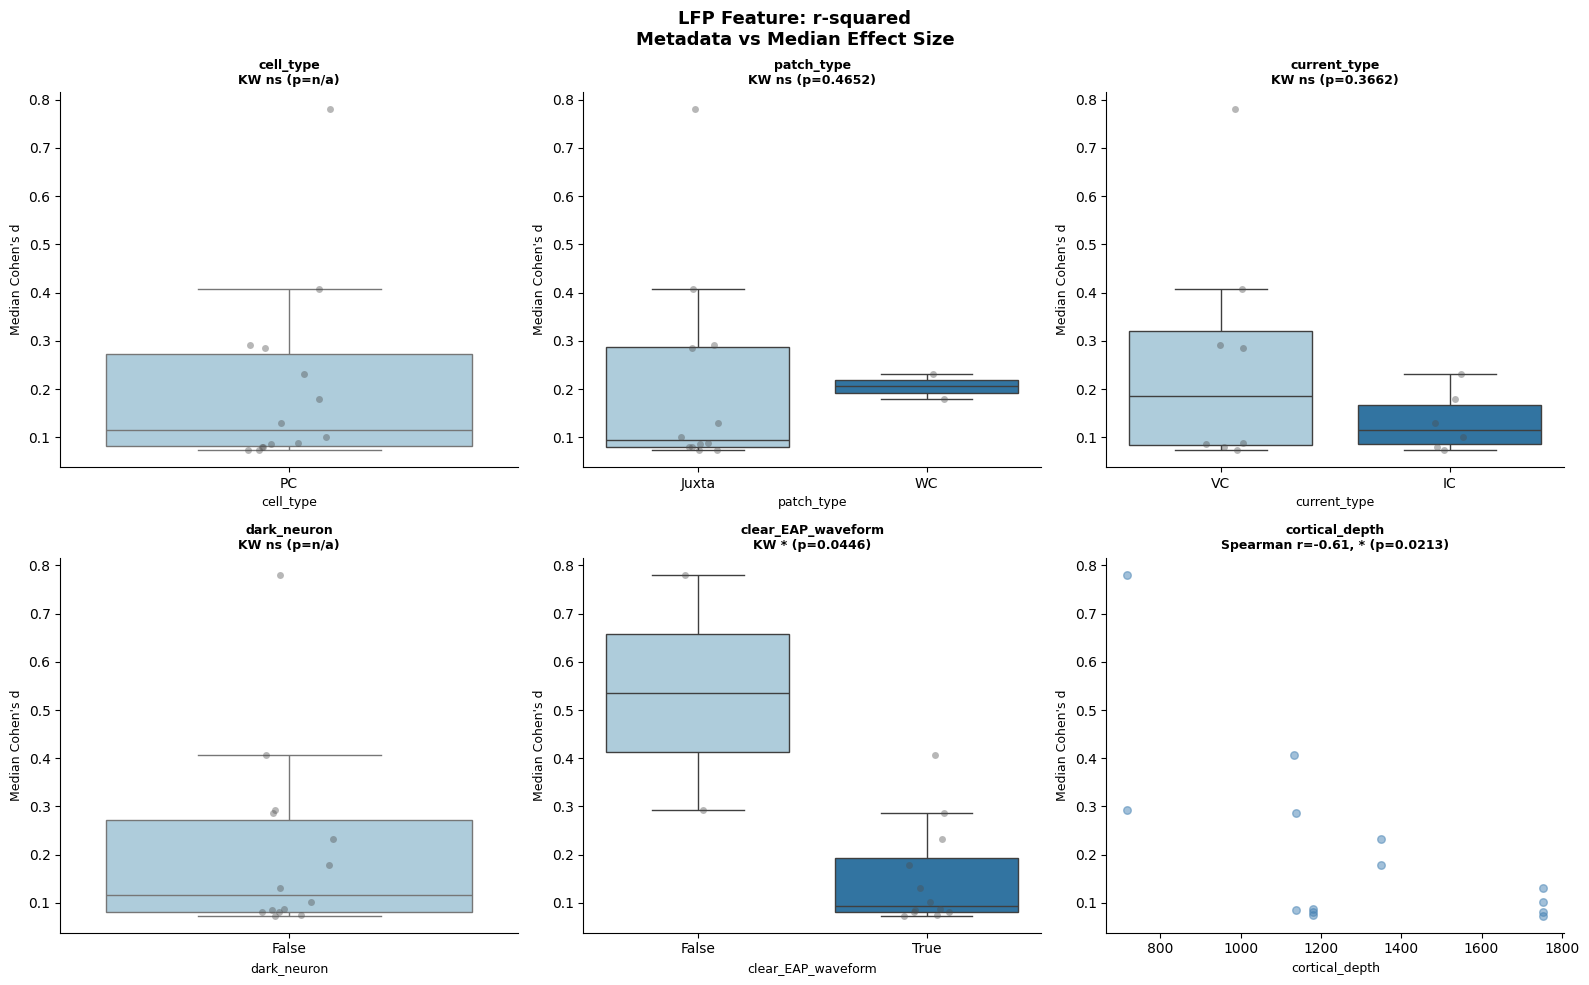

In [6]:
from scipy.stats import kruskal

cat_meta = ['cell_type', 'patch_type', 'current_type', 'dark_neuron', 'clear_EAP_waveform']
cont_meta = ['cortical_depth']

for lfp in lfp_feats:
    sub = df_merged[df_merged['lfp_feature'] == lfp].copy()
    n_plots = len(cat_meta) + len(cont_meta)
    fig, axes = plt.subplots(2, (n_plots + 1) // 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax_idx, col in enumerate(cat_meta + cont_meta):
        ax = axes[ax_idx]
        plot_sub = sub[['median_cohens_d', col]].dropna()
        if col in cont_meta:
            x = pd.to_numeric(plot_sub[col], errors='coerce')
            y = plot_sub['median_cohens_d']
            valid = np.isfinite(x) & np.isfinite(y)
            ax.scatter(x[valid], y[valid], alpha=0.5, s=30, color='steelblue')
            if valid.sum() >= 3:
                rho, p = spearmanr(x[valid], y[valid])
                sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                p_str = f'{p:.4f}' if p >= 0.0001 else '<0.0001'
                ax.set_title(f'{col}\nSpearman r={rho:.2f}, {sig} (p={p_str})', fontsize=9, fontweight='bold')
            ax.set_xlabel(col, fontsize=9)
            ax.set_ylabel("Median Cohen's d", fontsize=9)
        else:
            groups = [g['median_cohens_d'].values for _, g in plot_sub.groupby(col) if len(g) > 0]
            stat, p = kruskal(*groups) if len(groups) >= 2 else (np.nan, np.nan)
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            p_str = f'{p:.4f}' if pd.notnull(p) and p >= 0.0001 else ('<0.0001' if pd.notnull(p) else 'n/a')
            sns.boxplot(data=plot_sub, x=col, y='median_cohens_d', showfliers=False, palette='Paired', ax=ax)
            sns.stripplot(data=plot_sub, x=col, y='median_cohens_d', color='.3', alpha=0.4, ax=ax)
            ax.set_title(f'{col}\nKW {sig} (p={p_str})', fontsize=9, fontweight='bold')
            ax.set_xlabel(col, fontsize=9)
            ax.set_ylabel("Median Cohen's d", fontsize=9)
        sns.despine(ax=ax)

    for j in range(ax_idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'LFP Feature: {lfp}\nMetadata vs Median Effect Size', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Step 4: Does temporal component predict LFP significance?

Do cells with significant temporal drift (temporal_component=1) show more or stronger LFP effects?

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2353485372.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='temporal_component', y=metric, order=order,
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_21644/2353485372.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='temporal_component', y=metric, order=order,


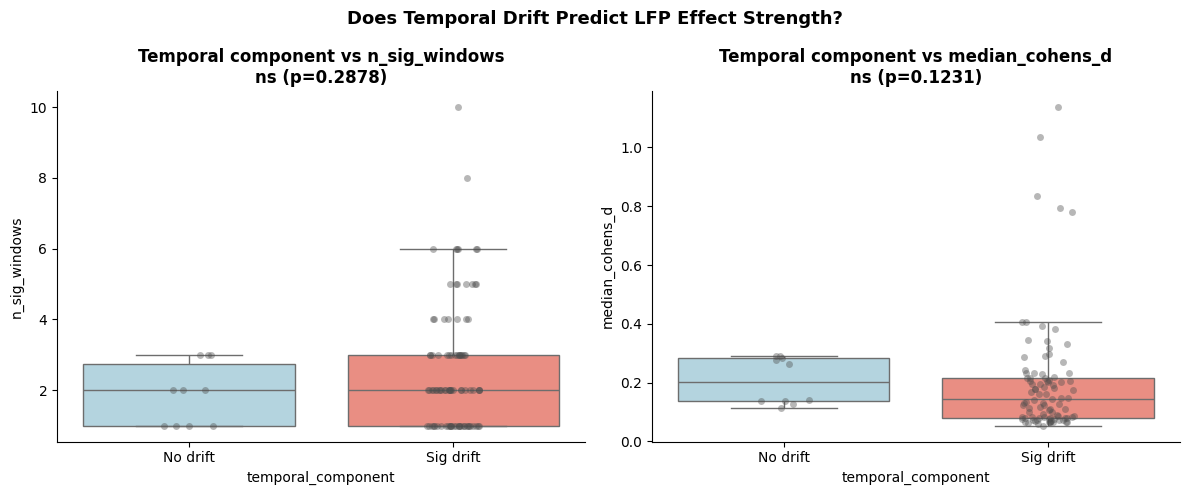

In [7]:
from scipy.stats import kruskal

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ['n_sig_windows', 'median_cohens_d']):
    sub = df_merged[['temporal_component', metric]].dropna()
    sub['temporal_component'] = sub['temporal_component'].astype(float).map({0.0: 'No drift', 1.0: 'Sig drift'})
    order = ['No drift', 'Sig drift']
    sns.boxplot(data=sub, x='temporal_component', y=metric, order=order,
                palette=['lightblue', 'salmon'], showfliers=False, ax=ax)
    sns.stripplot(data=sub, x='temporal_component', y=metric, order=order,
                  color='.3', alpha=0.4, ax=ax)
    groups = [g[metric].values for _, g in sub.groupby('temporal_component') if len(g) > 0]
    stat, p = kruskal(*groups) if len(groups) >= 2 else (np.nan, np.nan)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    p_str = f'{p:.4f}' if pd.notnull(p) and p >= 0.0001 else '<0.0001'
    ax.set_title(f'Temporal component vs {metric}\n{sig} (p={p_str})', fontweight='bold')
    sns.despine(ax=ax)

plt.suptitle('Does Temporal Drift Predict LFP Effect Strength?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 5: Summary table — which cell × spike feature × LFP feature combos are most interesting?

Filter to combos with significant LFP effects + strong clustering (high nRMSE or low cos_sim).

In [8]:
nRMSE_thresh = df_merged['nRMSE'].quantile(0.5)
cos_sim_thresh = df_merged['cos_sim'].quantile(0.5)

df_highlight = df_merged[
    (df_merged['n_sig_windows'] > 0) &
    ((df_merged['nRMSE'] >= nRMSE_thresh) | (df_merged['cos_sim'] <= cos_sim_thresh))
].sort_values('median_cohens_d', ascending=False)

cols_show = ['cell_id', 'spike_feature', 'lfp_feature', 'n_sig_windows', 'median_cohens_d',
             'nRMSE', 'cos_sim', 'temporal_rho', 'temporal_component',
             'cell_type', 'cortical_depth']
df_highlight[cols_show].reset_index(drop=True)

,cell_id,spike_feature,lfp_feature,n_sig_windows,median_cohens_d,nRMSE,cos_sim,temporal_rho,temporal_component,cell_type,cortical_depth
0,c10,peak_amp,Theta AUC,1,1.137399,0.059617,0.950757,-0.799044,1.0,PC,718.0
1,c10,peak_amp,Aperiodic Offset,2,1.034999,0.059617,0.950757,-0.799044,1.0,PC,718.0
2,c10,peak_amp,LFP Spectral Exponent,2,0.835794,0.059617,0.950757,-0.799044,1.0,PC,718.0
3,c10,peak_amp,Aperiodic Exponent,5,0.794828,0.059617,0.950757,-0.799044,1.0,PC,718.0
4,c10,peak_amp,r-squared,2,0.780490,0.059617,0.950757,-0.799044,1.0,PC,718.0
...,...,...,...,...,...,...,...,...,...,...,...
61,c21,peak_amp,LFP Std,6,0.067610,0.145846,0.884923,-0.227997,1.0,PC,1754.0
62,c21,peak_amp,Theta AUC,1,0.066282,0.145846,0.884923,-0.227997,1.0,PC,1754.0
63,c19,spk_times_ms,Theta AUC,1,0.065985,0.076716,0.974761,0.865631,1.0,PC,1180.9
64,c21,peak_amp,Gamma AUC,1,0.065076,0.145846,0.884923,-0.227997,1.0,PC,1754.0
